# Part 1 :Regularized Cost and Gradient Descent for linear regression

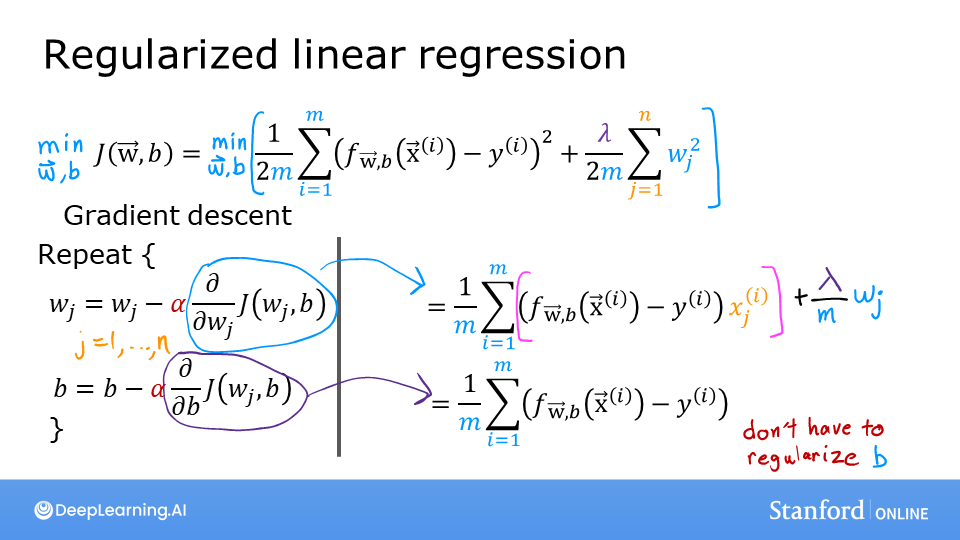



In [812]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

In [813]:
# Features: size (sqft), age (years)
X = np.array([
    [2100, 20],
    [1600, 15],
    [2400, 25],
    [1416, 20],
    [3000, 30],
    [1985, 18],
    [1534, 15],
    [1427, 20],
    [1380, 18],
    [1494, 17]
])

# Prices in $1000s
y = np.array([400, 330, 369, 232, 540, 315, 305, 199, 220, 230])

# Normalize features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std # z-score normalization



In [814]:
X.shape,y.shape

((10, 2), (10,))


### Cost function for regularized linear regression

The equation for the cost function regularized linear regression is:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2  + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2 \tag{1}$$ 
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{2} $$ 


Compare this to the cost function without regularization (which you implemented in  a previous lab), which is of the form:

$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 $$ 

The difference is the regularization term,  <span style="color:blue">
    $\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$ </span> 
    
Including this term encourages gradient descent to minimize the size of the parameters. Note, in this example, the parameter $b$ is not regularized. This is standard practice.

Below is an implementation of equations (1) and (2). Note that this uses a *standard pattern for this course*,   a `for loop` over all `m` examples.

In [815]:
def compute_cost_LR(x,y,w,b,lambda_ = 1):
    m = x.shape[0] # training examples
    n = len(w) # features 
    cost = 0.0 # initial cost 

    # compute the MSE cost for the first term 
    for i in range(m): 
        y_hat = np.dot(x[i],w) + b  # prediction : xi * w + b
        
        cost += (y_hat - y[i])**2 # ((xi * w + b) - yi)^2  squared error
    cost = cost / (2*m) # avg mse overe all examples


    # Regularized L2 (the second term)
    reg_cost = 0.0
    for j in range(n):
        reg_cost+= w[j]**2 # sum of squared weights   
        
    reg_cost = (lambda_/(2*m)) * reg_cost # lambda/2m * (sum of all w's (whights) squared) 
    
    total_cost = cost + reg_cost

    # Return the total MSE + L2
    return total_cost


    

In [816]:
np.random.seed(1)
w_tmp = np.random.rand(X_norm.shape[1]).reshape(-1,) 
b_tmp = 0
lambda_tmp = 0.7
cost_tmp = compute_cost_LR(X_norm,y,w_tmp,b_tmp,lambda_tmp)
print("Regularized cost:", cost_tmp)

Regularized cost: 54095.57734413571


>This high cost is mostly caused by random bad initial weights (w_tmp) and a non-optimized b
---
# Next we will use `Gradient descent` to optimize `w` and `b` 
---

## Gradient descent with regularization
The basic algorithm for running gradient descent does not change with regularization, it is:
$$\begin{align*}
&\text{repeat until convergence:} \; \lbrace \\
&  \; \; \;w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1} \\ 
&  \; \; \;  \; \;b = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \\
&\rbrace
\end{align*}$$
Where each iteration performs simultaneous updates on $w_j$ for all $j$.

What changes with regularization is computing the gradients.

---
### Computing the Gradient with regularization (both linear/logistic)
The gradient calculation for both linear and logistic regression are nearly identical, differing only in computation of $f_{\mathbf{w}b}$.
$$\begin{align*}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)}  +  \frac{\lambda}{m} w_j \tag{2} \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3} 
\end{align*}$$

* m is the number of training examples in the data set      
* $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target

      
* For a  <span style="color:blue"> **linear** </span> regression model  
    $f_{\mathbf{w},b}(x) = \mathbf{w} \cdot \mathbf{x} + b$  
* For a <span style="color:blue"> **logistic** </span> regression model  
    $z = \mathbf{w} \cdot \mathbf{x} + b$  
    $f_{\mathbf{w},b}(x) = g(z)$  
    where $g(z)$ is the sigmoid function:  
    $g(z) = \frac{1}{1+e^{-z}}$   
    
The term which adds regularization is  the <span style="color:blue">$\frac{\lambda}{m} w_j $</span>.

In [817]:
def compute_gradient_LR(x, y, w, b, lambda_):
    m, n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    # ----- Compute gradients -----
    

    for i in range(m): # loop over all training examples
        error = np.dot(x[i], w) + b - y[i] # Error
        dj_db += error 
        

        for j in range(n): # loop over all features 
            dj_dw[j] += error * x[i, j]
        

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    # ----- Add L2 regularization -----
    for j in range(n):
        dj_dw[j] += (lambda_ / m) * w[j] # only dj/dw have to regularized 

    return dj_dw, dj_db

# Run the compute gradient function

In [818]:
np.random.seed(1)
w_tmp = np.random.rand(X_norm.shape[1]).reshape(-1,) 
b_tmp = 0
lambda_tmp = 0.7

dj_dw_tmp , dj_db_tmp = compute_gradient_LR(X_norm,y,w_tmp,b_tmp,lambda_tmp)

print(f"dj_db {dj_db_tmp}")

print(f"dj_dw Regularized: {dj_dw_tmp.tolist()}")

dj_db -314.0
dj_dw Regularized: [-91.26328163937976, -65.99725307544567]


# Gradient descent function

In [819]:
def gradient_descent(x,y,w_in,b_in,alpha,num_iters,lambda_):

    j_history = []
    dj_dw_history = []
    dj_db_history = []
    
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw,dj_db = compute_gradient_LR(x,y,w,b,lambda_)
        # parameter updates 
        w = w - alpha * dj_dw 
        b = b - alpha * dj_db

        if i < 100000 : # cost history
            j_history.append(compute_cost_LR(x,y,w_in,b,lambda_))
            dj_dw_history.append(dj_dw.copy())
            dj_db_history.append(dj_db)
    

        if i % 100 == 0 :
            print(f"Iteration {i:4d}: Cost {j_history[-1]:8.2f}")

    return w,b,j_history,dj_dw_history,dj_db_history
            

# Run Gradient desccent

In [820]:
# settings for GD

np.random.seed(1)
w_tmp = np.random.rand(X_norm.shape[1]).reshape(-1,) 
b_tmp = 0
lambda_tmp = 0.7
alpha = 0.01
iters = 1000

In [821]:
w_fin,b_fin,j_history,dj_dw_hist,dj_db_hist = gradient_descent(X_norm,y,w_tmp,b_tmp,alpha,iters,lambda_tmp)

Iteration    0: Cost 53114.55
Iteration  100: Cost 11271.07
Iteration  200: Cost  5664.89
Iteration  300: Cost  4913.78
Iteration  400: Cost  4813.15
Iteration  500: Cost  4799.66
Iteration  600: Cost  4797.86
Iteration  700: Cost  4797.61
Iteration  800: Cost  4797.58
Iteration  900: Cost  4797.58


# Our model :

$ \hat{y} = w_1 x_1 + w_2 x_2 + b $

Where:
- $ \hat{y} $ is the predicted output
- $ x_1, x_2 $ are the input features (e.g., house size, age)
- $ w_1, w_2 $ are the corresponding weights
- $ b $ is the bias term

In [822]:
m = X_norm.shape[0]
for i in range(m):
    print(f"prediction: {np.dot(X_norm[i], w_fin) + b_fin}, target value: {y[i]}")

prediction: 361.6925598605309, target value: 400
prediction: 281.06728263046193, target value: 330
prediction: 406.2130444420487, target value: 369
prediction: 238.21416900248607, target value: 232
prediction: 504.89071799639316, target value: 540
prediction: 344.7869858441375, target value: 315
prediction: 269.1527010564401, target value: 305
prediction: 240.1999325981564, target value: 199
prediction: 235.5699880822704, target value: 220
prediction: 258.07706077020634, target value: 230


In [823]:
print(f"Optimal W,b Found by GD W = {w_fin} , b = {b_fin}")

Optimal W,b Found by GD W = [91.70035231 -8.43638295] , b = 313.98644422831313


In [824]:
print(f"First cost = {j_history[0]} , minimum cost (last) = {j_history[-1]} ")

First cost = 53114.54714413571 , minimum cost (last) = 4797.577436015179 


# visualization
---
## predictions vs actual 

In [825]:
y_pred = np.dot(X_norm,w_fin)+b_fin

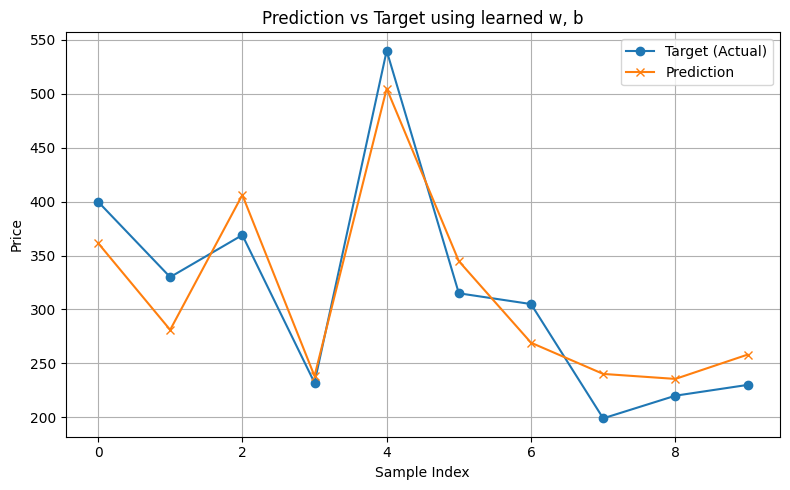

In [826]:
plt.figure(figsize=(8, 5))
plt.plot(y, label='Target (Actual)', marker='o')
plt.plot(y_pred, label='Prediction', marker='x')
plt.title('Prediction vs Target using learned w, b')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Cost function vs iterations 

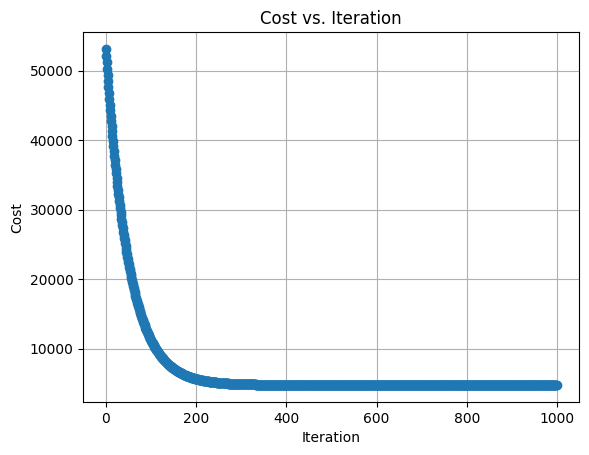

In [827]:

plt.plot(j_history, marker='o')
plt.title('Cost vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


# Derivatives dj/dw , dj/db vs iterations

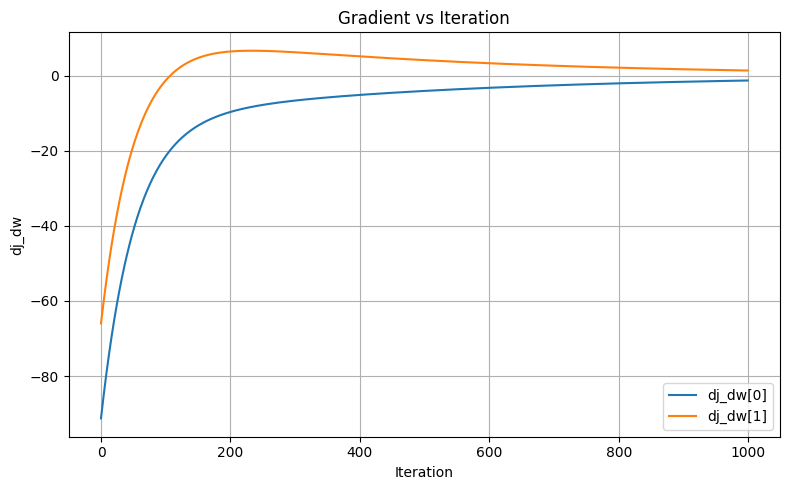

In [828]:

dj_dw_array = np.array(dj_dw_hist)

# Plot gradient history for each weight
plt.figure(figsize=(8, 5))
for i in range(dj_dw_array.shape[1]):
    plt.plot(dj_dw_array[:, i], label=f'dj_dw[{i}]')

plt.title('Gradient vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('dj_dw')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


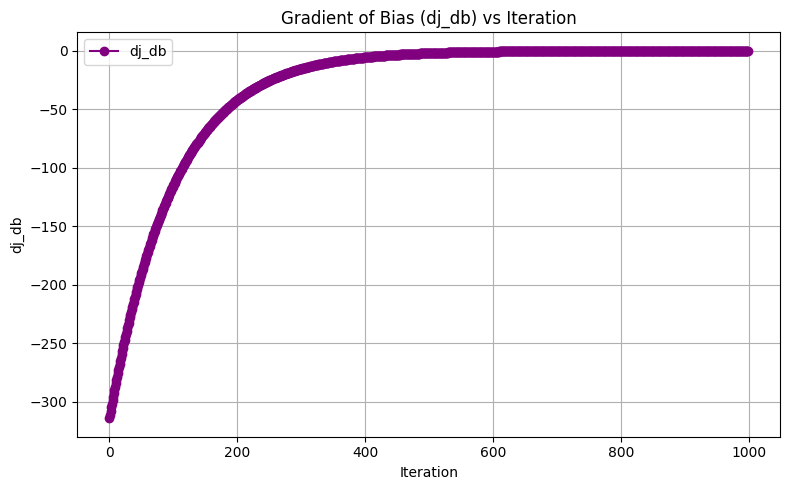

In [829]:
plt.figure(figsize=(8, 5))
plt.plot(dj_db_hist, marker='o', color='purple', label='dj_db')
plt.title('Gradient of Bias (dj_db) vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('dj_db')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

---
# Part 2 : Regularized Logistic Regression

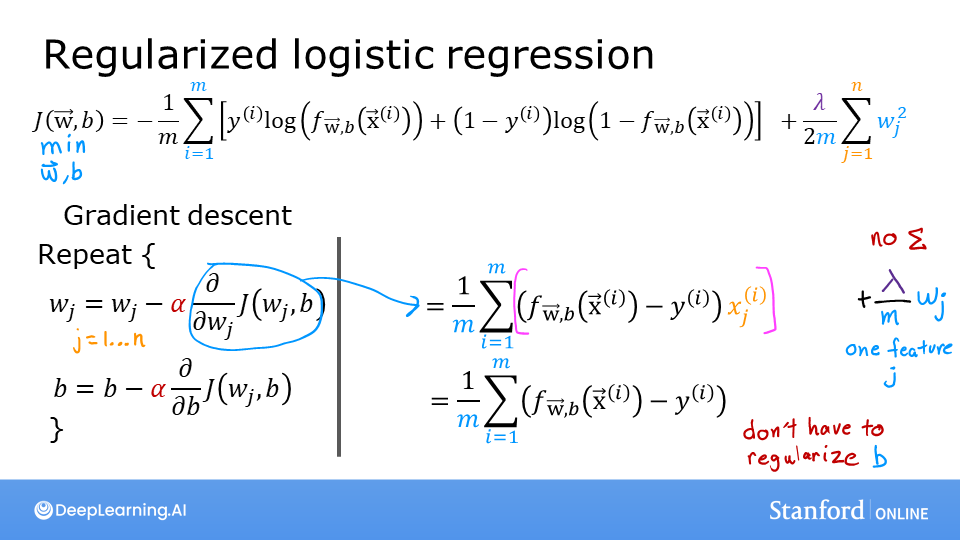



### Cost function for regularized logistic regression
For regularized **logistic** regression, the cost function is of the form
$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2 \tag{3}$$
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = sigmoid(\mathbf{w} \cdot \mathbf{x}^{(i)} + b)  \tag{4} $$ 

Compare this to the cost function without regularization (which you implemented in  a previous lab):

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right] $$

As was the case in linear regression above, the difference is the regularization term, which is    <span style="color:blue">
    $\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$ </span> 

Including this term encourages gradient descent to minimize the size of the parameters. Note, in this example, the parameter $b$ is not regularized. This is standard practice. 

In [830]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))



def compute_cost_LG(x,y,w,b,lambda_ = 1):
    m,n = x.shape
    cost = 0.0
    reg_cost = 0

    # compute the cost
    for i in range(m):
        z_i = np.dot(x[i],w) + b # linear model
        y_hat = sigmoid(z_i) # predictions
        cost+= -y[i]*np.log(y_hat) - (1-y[i])*np.log(1-y_hat) # cost for Logistic R
    
    cost = cost/m

    # compute the regularized cost 
    for j in range(n):
        reg_cost += (w[j]**2)
        
    reg_cost = (lambda_/(2*m)) * reg_cost

    # cost + regularized cost
    total_cost = reg_cost + cost
    return total_cost
        

In [831]:
np.random.seed(1)
X_tmp = np.random.rand(5,6)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1,)-0.5
b_tmp = 0.5
lambda_tmp = 0.7
cost_tmp = compute_cost_LG(X_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print("Regularized cost:", cost_tmp)

Regularized cost: 0.6850849138741673


### Gradient function for regularized logistic regression

In [854]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

def compute_gradient_LG(x, y, w, b, lambda_):
    m, n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        error = np.dot(x[i], w) + b - y[i]  # dot returns scalar 
        dj_db += error
        for j in range(n):
            dj_dw[j] += error * x[i, j]

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    # Add L2 regularization only to dj_dw
    for j in range(n):
        dj_dw[j] += (lambda_ / m) * w[j]

    return dj_dw, dj_db



In [833]:
np.random.seed(1)
X_tmp = np.random.rand(5,3)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1])
b_tmp = 0.5
lambda_tmp = 0.7
dj_dw_tmp, dj_db_tmp =  compute_gradient_LG(X_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print(f"dj_db: {dj_db_tmp}", )
print(f"Regularized dj_dw:\n {dj_dw_tmp.tolist()}", )

dj_db: 0.6648774569425726
Regularized dj_dw:
 [0.29653214748822276, 0.4911679625918033, 0.21645877535865857]


# Logistic GD

In [834]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, lambda_): 
    J_history = []
    w = w_in.copy()  # Avoid modifying original weights
    b = b_in
    
    for i in range(num_iters):
        # Get gradients
        dj_dw, dj_db = compute_gradient_LG(X, y, w, b, lambda_)

        # Update weights
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Track cost
        if i < 100000:
            J_history.append(compute_cost_LG(X, y, w, b, lambda_))

        # Print progress
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:.4f}")

    return w, b, J_history


In [835]:
np.random.seed(1)
X_tmp = np.random.rand(5,3)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).flatten()  # shape: (3,)
b_tmp = 0.5
lambda_tmp = 0.01
alpha =0.01
iters = 1000

w_fin, b_fin,j_hist =  gradient_descent(X_tmp, y_tmp, w_tmp, b_tmp,alpha,iters,lambda_tmp)



Iteration    0: Cost 0.9152
Iteration  100: Cost 0.7499
Iteration  200: Cost 0.7142
Iteration  300: Cost 0.7014
Iteration  400: Cost 0.6939
Iteration  500: Cost 0.6882
Iteration  600: Cost 0.6832
Iteration  700: Cost 0.6788
Iteration  800: Cost 0.6747
Iteration  900: Cost 0.6710


# Prediction and ploting

In [838]:

def predict(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

def predict_class(X, w, b, threshold=0.5):
    return (predict(X, w, b) >= threshold).astype(int)


In [839]:
y_pred_probs = predict(X_tmp, w_fin, b_fin)
y_pred_class = predict_class(X_tmp, w_fin, b_fin)

print("Predicted probabilities:", y_pred_probs)
print("Predicted class labels:", y_pred_class)
print("True labels:", y_tmp)


Predicted probabilities: [0.5582981  0.60166916 0.6054427  0.69378063 0.50979779]
Predicted class labels: [1 1 1 1 1]
True labels: [0 1 0 1 0]


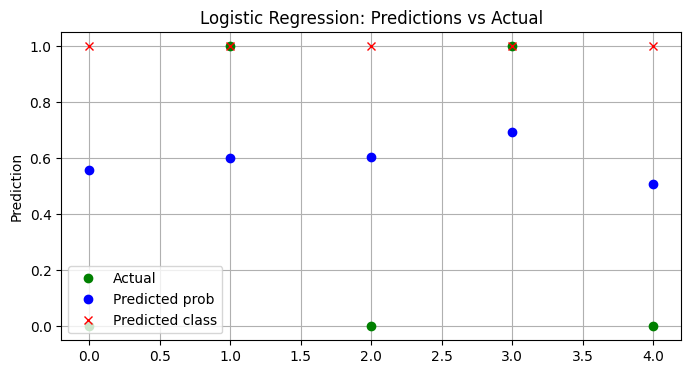

In [846]:


# Plot
plt.figure(figsize=(8, 4))
plt.plot(y_tmp, 'go', label='Actual')           # green = actual
plt.plot(y_pred_probs, 'bo', label='Predicted prob') # blue = predicted prob
plt.plot(y_pred_class, 'rx', label='Predicted class') # red = predicted class
plt.title("Logistic Regression: Predictions vs Actual")
plt.ylabel("Prediction")
plt.legend()
plt.grid()
plt.show()
